<a href="https://colab.research.google.com/github/KaisaridiSofia/leaspy_tutorial/blob/mixture_notebook/notebooks/mixture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# DEV, TO DELETE BEFORE MERGING TO MAIN: clone the fork/branch instead of main (delete the leaspy_tutorial folder to re-pull)
# BRANCH = "main"
# REPO = "https://github.com/aramis-lab/leaspy_tutorial"
BRANCH = "fit_notebook"
REPO = "https://github.com/KaisaridiSofia/leaspy_tutorial"

import importlib.util, pathlib, subprocess, sys

IN_COLAB = importlib.util.find_spec("google.colab") is not None
pip = [sys.executable, "-m", "pip", "install", "-q"]

if IN_COLAB:
    if importlib.util.find_spec("leaspy") is None:
        subprocess.run(pip + ["--no-deps",
    "leaspy @ git+https://github.com/aramis-lab/leaspy.git@v2.1.0"], check=True)
        subprocess.run(pip + ["lifelines"], check=True)   # dep Colab may lack
    if importlib.util.find_spec("fitz") is None:
        subprocess.run(pip + ["pymupdf"], check=True)
    if not pathlib.Path("leaspy_tutorial").exists():
        subprocess.run(["git", "clone", "-q", "--branch", BRANCH, REPO], check=True)
    sys.path.insert(0, "leaspy_tutorial")
else:
    for _root in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (_root / "tutolib").is_dir():
            sys.path.insert(0, str(_root)); break

import tutolib as tp
print("tutolib", tp.__version__, "loaded")

tutolib 0.1.0 loaded


In [4]:
import os

import matplotlib.pyplot as plt
import fitz
from IPython.display import Image, display

import numpy as np
import pandas as pd
import matplotlib.image as mpimg
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, r2_score

import leaspy
from leaspy.datasets import load_dataset
from leaspy.io.data import Data
from leaspy.models import LogisticModel
from leaspy.io.logs.visualization.plotting import Plotting

print(f"leaspy {leaspy.__version__}")

leaspy 2.1.0


# Mixture Model

A mixture model is used when we suspect that there are different progression profiles that co-exist in the same population. Mixed-effect models usually assume that all individuals are distributed around the same average trajectory but this might obscure parts of individual variability when there are cluster of patient trajectories with distinct profiles.

The mixture model that is implemented in `leaspy` is a probabilistic finite logistic model. That means:
- __probabilistic:__ it assigns at each individual probabilities of belonging in each cluster rather than cluster labels (soft clustering)
- __finite:__ it can estimate a predefined fixed number of clusters
- __logistic:__ it can estimate continuous logistic trajectories.


So like the simple logistic model we need a dataset with repeated observations of continuous scores that are normalized.

In [5]:
leaspy_root = os.path.dirname(leaspy.__file__)
data_path = os.path.join(leaspy_root, "datasets/data/simulated_data_for_mixture.csv")

all_data = pd.read_csv(data_path, sep=";", decimal=",")
all_data["ID"] = all_data["ID"].ffill()
all_data = all_data.set_index(["ID", "TIME"])
all_data.head()

score_1_normalized  score_2_normalized  score_3_normalized  \
ID     TIME                                                                    
subj_1 50.159062            0.197863            0.057787            0.095305   
       66.713371            0.418290            0.139975            0.021792   
       68.994947            0.397005            0.149633            0.040861   
       73.009543            0.330076            0.127369            0.098300   
       80.948301            0.530554            0.117444            0.159612   

                  score_4_normalized  score_5_normalized  score_6_normalized  
ID     TIME                                                                   
subj_1 50.159062            0.141747            0.265511            0.397614  
       66.713371            0.119112            0.481825            0.456491  
       68.994947            0.128334            0.388164            0.394283  
       73.009543            0.348438            0.473187            0.418984  
       80.948301            0.339971            0.468804            0.591484

Then we need to load the `LogisticMultivariateMixtureModel` from the library and fit it with the data with our chosen number of clusters.

In [8]:
from leaspy.models import LogisticMultivariateMixtureModel

leaspy_data = Data.from_dataframe(all_data)

In [10]:
model = LogisticMultivariateMixtureModel(
    name="multi",
    source_dimension=2,
    dimension=6,
    n_clusters=3,
)

model.fit(leaspy_data, "mcmc_saem", seed=1312, n_iter=100, progress_bar=False)
model.summary()


Fit with `AlgorithmName.FIT_MCMC_SAEM` took: 25.10s


                                 Model Summary                                  
Model Name: mixture_logistic
Model Type: LogisticMultivariateMixtureModel
Features (6): score_1_normalized, score_2_normalized, score_3_normalized,
    score_4_normalized, score_5_normalized, score_6_normalized
Sources (2): Source 0 (s0), Source 1 (s1)
Clusters (3): Cluster 0 (c0), Cluster 1 (c1), Cluster 2 (c2)
Observation Models: gaussian-diagonal
Neg. Log-Likelihood: -5338.2385
Parameters: 46
BIC: -93961.79
AIC: -94187.55
ICL: -93830.93

Training Metadata
--------------------------------------------------------------------------------
Algorithm: mcmc_saem
Seed: 1312
Iterations: 100

Data Context
--------------------------------------------------------------------------------
Subjects: 1000
Visits: 6000
Total Observations: 36000
Leaspy Version: 2.1.0

Population Parameters
--------------------------------------------------------------------------------
  betas_mean:
                          s0        s1

The most appropriate metric for a mixture model is the ICL criterion, which refines the BIC by factoring in clustering quality (entropy) while still penalizing model complexity.

In [11]:
model.summary().icl

-93830.93478461399

As with the standard model we can also do a personalization to acess the individual parameters

In [ ]:
ip = model.personalize(leaspy_data, "scipy_minimize", seed=0, progress_bar=False)
ip_df = ip.to_dataframe()
ip_with_probs = model.get_individual_probabilities(ip_df)
ip_with_probs.head()

In addition to the standard individual parameters, we obtain the posterior probabilities of cluster membership for each individual, as well as the hard cluster assignments determined by the maximum probability.

## Task:

Can you fit a model with two clusters and compare their ICLs?

In [12]:
## Answer:
#model_2 = LogisticMultivariateMixtureModel(
#    name="multi",
#    source_dimension=2,
#    dimension=6,
#    n_clusters=2,
#)

#model_2.fit(leaspy_data, "mcmc_saem", seed=1312, n_iter=100, progress_bar=False)
#model_2.summary().icl

## Plotting

Leaspy's mixture model comes with adapted plotting tools as well. We can visualize the average trajectory:

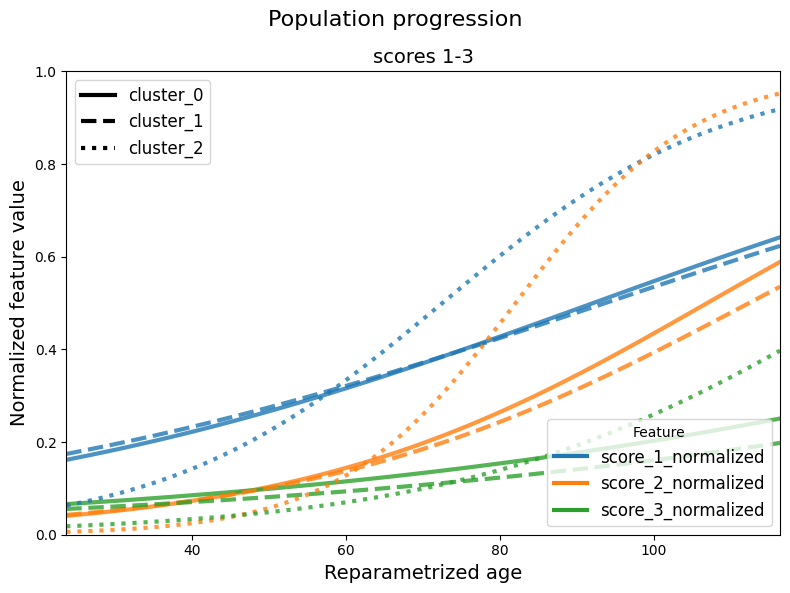

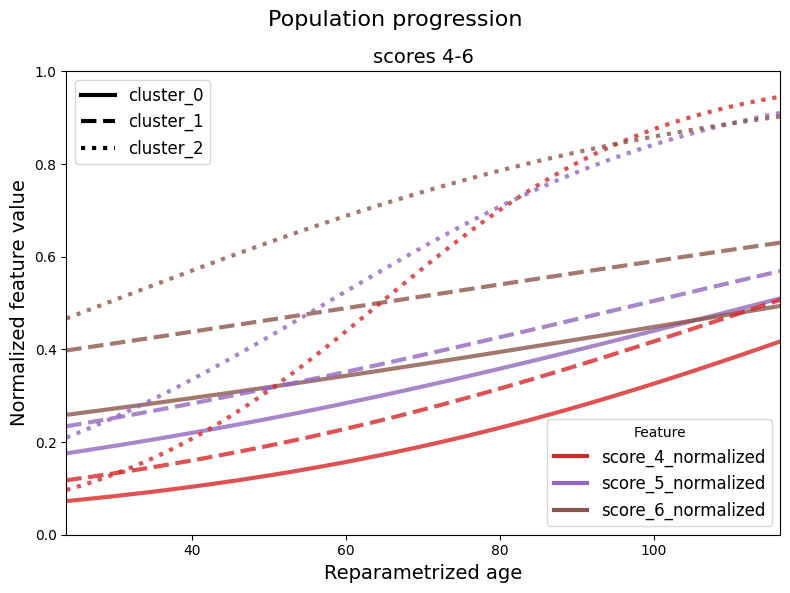

In [7]:
from leaspy.io.logs.visualization.plotting import Plotting

leaspy_plotting = Plotting(model)
leaspy_plotting.average_trajectory_cluster(
    alpha=0.8,
    linewidth=3,
    figsize=(14, 6),
    n_std_left=4,
    n_std_right=5
    )
plt.show()

The individual reparametrized observations.

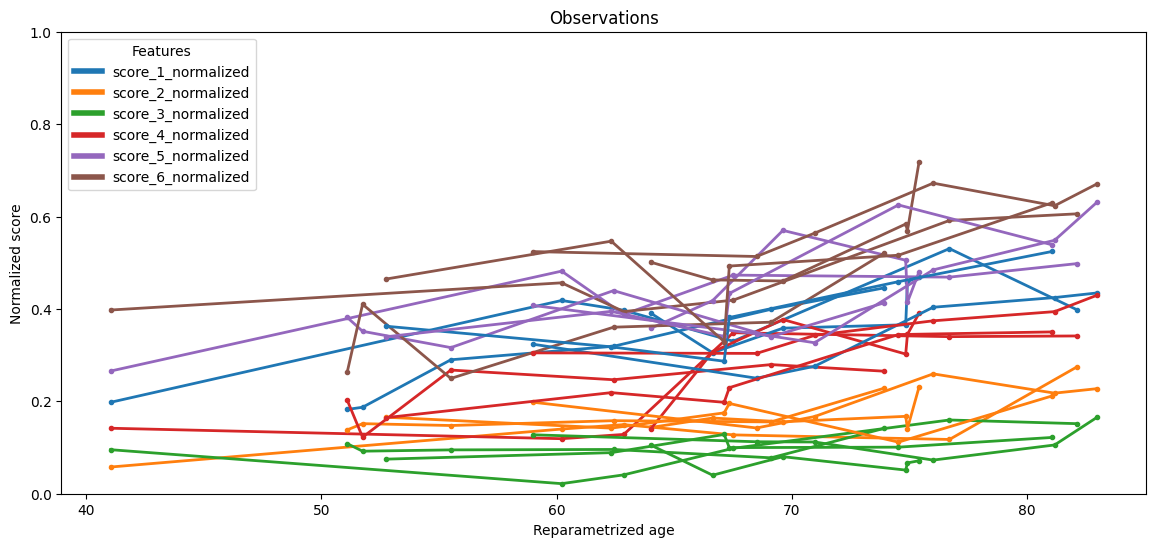

In [9]:
ax = leaspy_plotting.patient_observations_reparametrized(
    leaspy_data, ip_with_probs, figsize=(14, 6),
    patients_idx=['subj_1','subj_2','subj_3','subj_4','subj_5'],
)
plt.show()

And an individual trajectory for a selected patient.

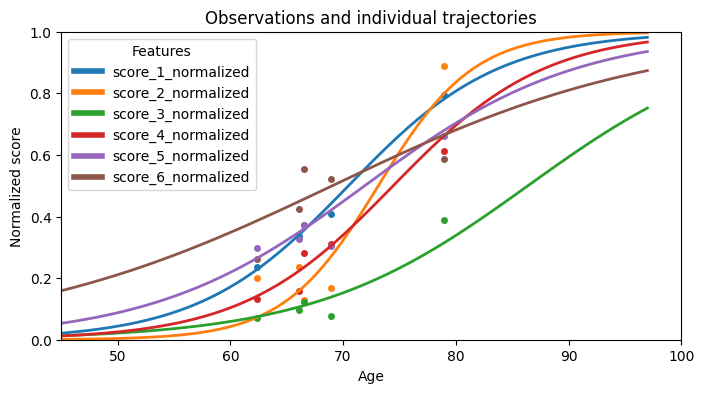

In [10]:
ax = leaspy_plotting.patient_trajectories(
    leaspy_data,
    ip_with_probs,
    patients_idx=['subj_12']
)
ax.set_xlim(45, 100)
plt.show()